# Compare different AF media completed for different target growth rates

### 1. Imports and SetUp

In [13]:
import pandas as pd
import os
from micom import load_pickle, Community
import matplotlib.pyplot as plt
import seaborn as sns
from cobra.exceptions import OptimizationError
import numpy as np

import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')
from functions import * 

In [14]:
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/final"


taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [15]:
# load completed medium files
c01 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c01i0127.csv")
c05 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c05i0527.csv")
c1 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c1i127.csv")
c2 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c2i227.csv")
c3 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c3i327.csv")
c5 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c5i527.csv")

### 2. load media and create communities

In [16]:
# convert media to dicts 
c01 = create_medium(c01)
c05 = create_medium(c05)
c1 = create_medium(c1)
c2 = create_medium(c2)
c3 = create_medium(c3)
c5 = create_medium(c5)

In [17]:
mediadict = {"c01" : c01, "c05": c05, "c1": c1, "c2": c2, "c3": c3, "c5": c5}

In [18]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [19]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [20]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [21]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

### 3. Optimize community growth on these different media 

In [22]:
compare_growth_media = {}

for medium_id, medium in mediadict.items():
    print(f"Running growth comparison for medium {medium_id}...")
    HvSC1.medium = medium
    HvSC2.medium = medium

    try:
        sol1 = HvSC1.optimize()
        hvsc1_growth = sol1.growth_rate
    except OptimizationError:
        # Log None or 0 if the medium cannot sustain any growth
        hvsc1_growth = None 
        
    try:
        sol2 = HvSC2.optimize()
        hvsc2_growth = sol2.growth_rate
    except OptimizationError:
        hvsc2_growth = None

    # 3. Save the results (including the failed states)
    compare_growth_media[medium_id] = {
        "HvSC1_growth": hvsc1_growth,
        "HvSC2_growth": hvsc2_growth,
        "HvSC1_feasible": hvsc1_growth is not None,
        "HvSC2_feasible": hvsc2_growth is not None
    }

Running growth comparison for medium c01...
Running growth comparison for medium c05...
Running growth comparison for medium c1...
Running growth comparison for medium c2...
Running growth comparison for medium c3...
Running growth comparison for medium c5...


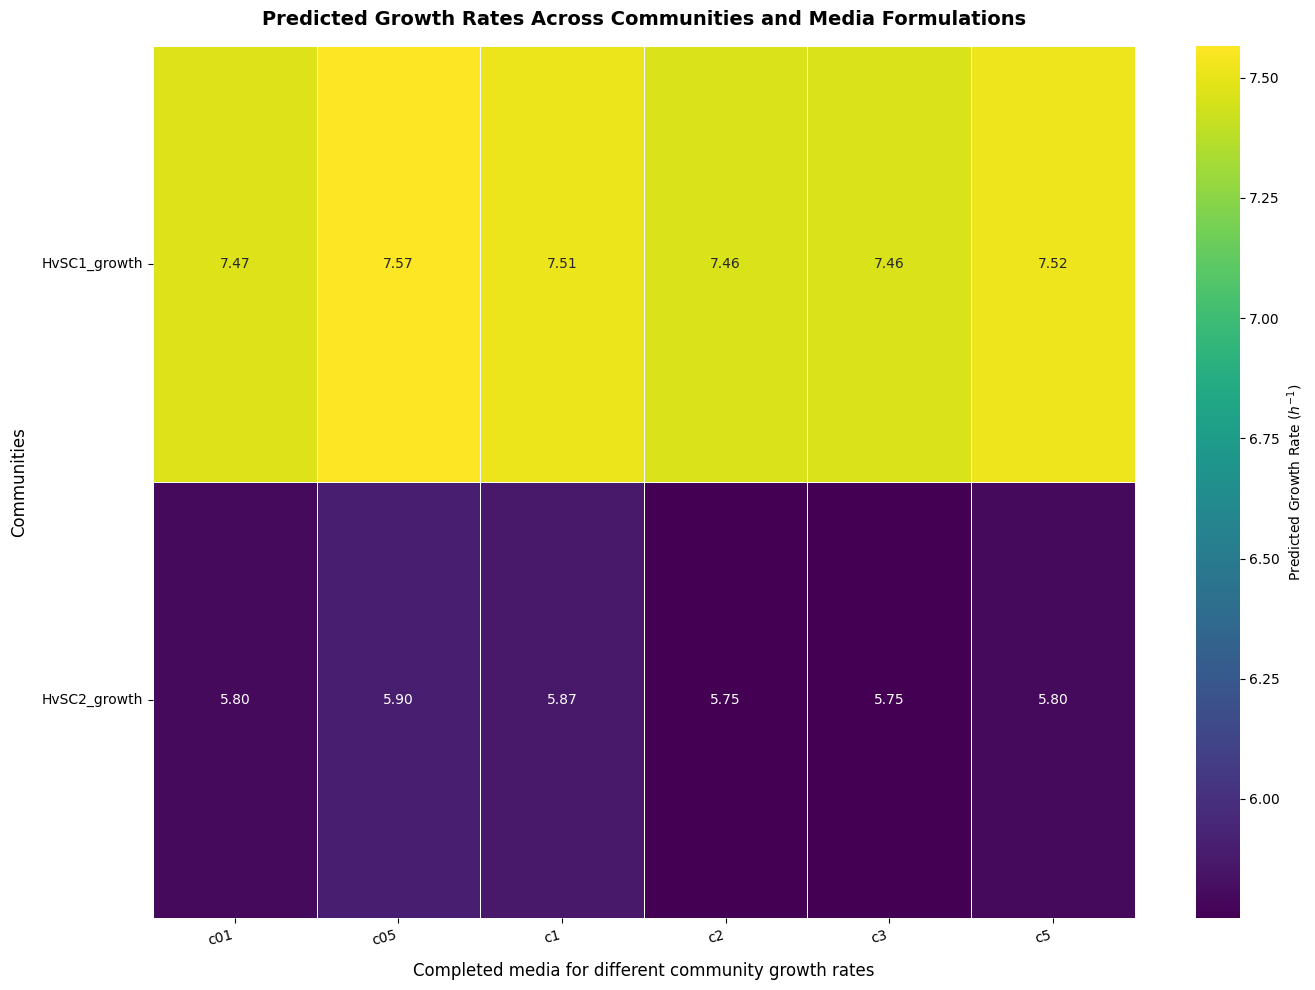

In [23]:
# 1. Isolate the rows you want and FORCE them into a float data type
plot_data = pd.DataFrame.from_dict(compare_growth_media).loc[['HvSC1_growth', 'HvSC2_growth']].astype(float)

# 2. Safely fill any lingering NaNs (from failed optimizations) with 0.0
plot_data = plot_data.fillna(0.0)

# 3. Setup the plotting canvas
fig, ax = plt.subplots(figsize=(14, 10))

# 4. Generate the heatmap with the cleaned, float-only data
sns.heatmap(
    plot_data, 
    annot=True,              
    cmap='viridis',          
    fmt=".2f",               
    linewidths=0.5,          
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

# 5. Labels and styling for publication quality
ax.set_title('Predicted Growth Rates Across Communities and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Completed media for different community growth rates', fontsize=12, labelpad=10)
ax.set_ylabel('Communities', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 4. Compare Media Compositions

In [33]:
active_metabolites = {}
for m_id, media_dict in mediadict.items():
    # Extracted from the dict if the flux value is greater than 1e-5
    active_metabolites[m_id] = {
        metabolite for metabolite, flux in media_dict.items() if flux > 1e-5
    }

all_media_names = list(mediadict.keys())

# =========================================================
# 1. METABOLITES SHARED IN ALL MEDIA
# =========================================================
# The intersection of all sets
shared_in_all_ids = set.intersection(*active_metabolites.values())

# Create a clean tracking DataFrame showing their average fluxes across layouts
shared_in_all = pd.DataFrame(index=list(shared_in_all_ids))
for m_id, series in mediadict.items():
    shared_in_all[f"{m_id}_flux"] = series

print(f"--- Shared in ALL media ({len(shared_in_all)} components) ---")
print(shared_in_all.head())


# =========================================================
# 2. METABOLITES UNIQUE TO ONLY ONE SPECIFIC MEDIUM LAYOUT
# =========================================================
unique_components = {}

for current_media in all_media_names:
    current_set = active_metabolites[current_media]
    
    # Union of all other media pools to subtract against
    other_sets = [active_metabolites[other] for other in all_media_names if other != current_media]
    all_others_combined = set.union(*other_sets)
    
    # Subtract to find strictly unique structural footprints
    unique_to_this_one = current_set - all_others_combined
    
    # Safely extract from dictionary using comprehension and convert to DataFrame
    if unique_to_this_one:
        media_dict_source = mediadict[current_media]
        # Build a temporary dict of only the unique metabolites and their fluxes
        unique_fluxes = {met: media_dict_source[met] for met in unique_to_this_one}
        
        # Convert cleanly into a structured DataFrame
        unique_components[current_media] = pd.DataFrame.from_dict(
            unique_fluxes, orient='index', columns=["Unique_Flux"]
        )
    else:
        # Keep an empty DataFrame structure if no unique items exist
        unique_components[current_media] = pd.DataFrame(columns=["Unique_Flux"])



# Example: Display only what was needed for your c01 simulation condition
print(f"\n--- Unique components only in 'c01' ({len(unique_components['c01'])} components) ---")
print(unique_components["c01"])

print(f"\n--- Unique components only in 'c1' ({len(unique_components['c1'])} components) ---")
print(unique_components["c1"])

print(f"\n--- Unique components only in 'c2' ({len(unique_components['c2'])} components) ---")
print(unique_components["c2"])

print(f"\n--- Unique components only in 'c3' ({len(unique_components['c3'])} components) ---")
print(unique_components["c3"])

print(f"\n--- Unique components only in 'c5' ({len(unique_components['c5'])} components) ---")
print(unique_components["c5"])

--- Shared in ALL media (48 components) ---
           c01_flux  c1_flux  c2_flux  c3_flux  c5_flux
EX_ca2_m     1000.0   1000.0   1000.0   1000.0   1000.0
EX_fe2_m     1000.0   1000.0   1000.0   1000.0   1000.0
EX_skm_m        0.1      0.1      0.1      0.1      0.1
EX_ni2_m     1000.0   1000.0   1000.0   1000.0   1000.0
EX_succ_m      10.0     10.0     10.0     10.0     10.0

--- Unique components only in 'c01' (1 components) ---
          Unique_Flux
EX_gam_m     0.000013

--- Unique components only in 'c1' (1 components) ---
            Unique_Flux
EX_dachi_m     0.000017

--- Unique components only in 'c2' (0 components) ---
Empty DataFrame
Columns: [Unique_Flux]
Index: []

--- Unique components only in 'c3' (0 components) ---
Empty DataFrame
Columns: [Unique_Flux]
Index: []

--- Unique components only in 'c5' (2 components) ---
             Unique_Flux
EX_ribflv_m     0.000115
EX_nmn_m        0.000016
